Processing CSV file with diagnostics...
=== CSV Processing Pipeline with Diagnostics + Row Dropping ===
🗑️ Dropping 1 incomplete row(s): [13]
Clean dataframe shape: (13, 160) (kept 13 rows)
✅ Clean + expanded data saved to ../user_study_raw_results_clean.csv and _expanded.csv

=== Creating Box Plots from Expanded Data ===
Total data points: 1040
Models: ['OSS' 'DAPO' 'QwQ+DAPO/OSS' 'QwQ+OSS/DAPO']
Criteria: ['Clarity of Steps' 'Ease of Following' 'Confidence' 'best-overall']


/tmp/ipykernel_41809/2459632258.py:213: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_data, labels=plot_labels, patch_artist=True)
/tmp/ipykernel_41809/2459632258.py:213: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_data, labels=plot_labels, patch_artist=True)
/tmp/ipykernel_41809/2459632258.py:213: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_data, labels=plot_labels, patch_artist=True)
/tmp/ipykernel_41809/2459632258.py:213: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support fo

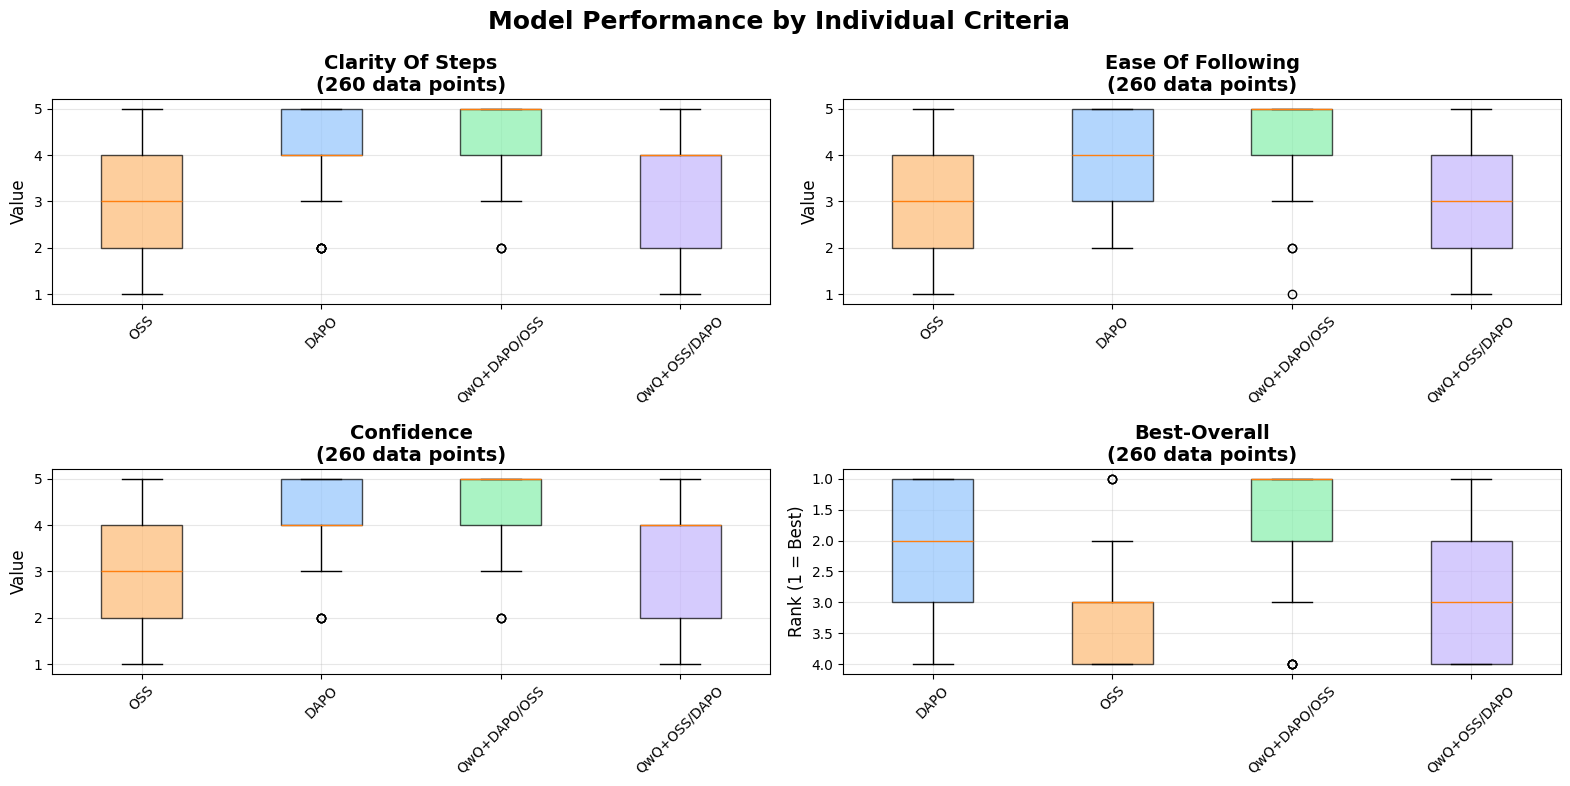

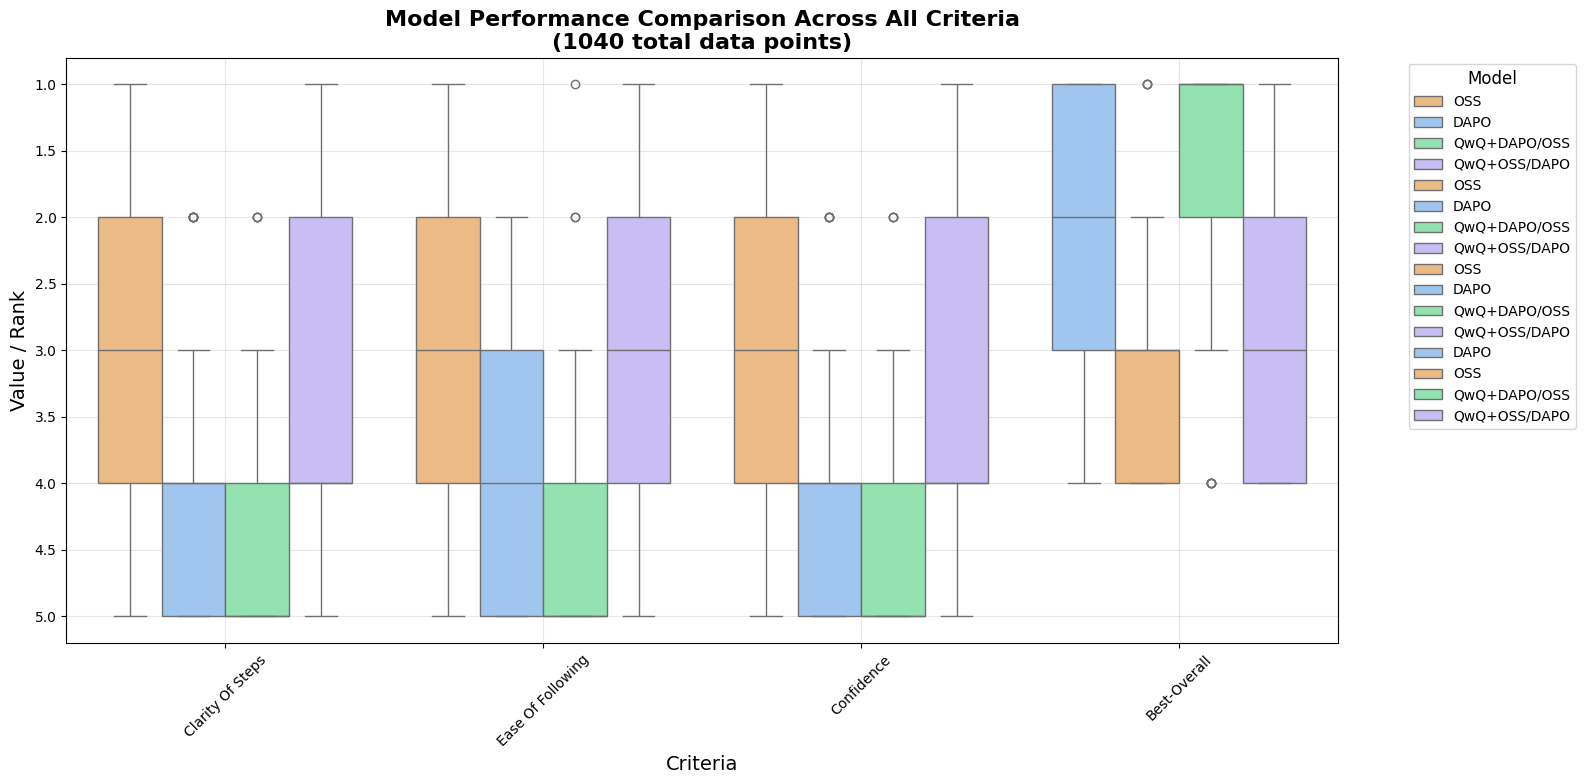


Box plots saved to PDF: user_study_latest_model_comparison_plots_boxplots.pdf

=== Summary Statistics (Expanded Data) ===
                                count   mean    std  min  max
model_clean  criterion_clean                                 
DAPO         Best-Overall          65  2.262  1.065  1.0  4.0
             Clarity Of Steps      65  4.046  0.926  2.0  5.0
             Confidence            65  4.077  0.889  2.0  5.0
             Ease Of Following     65  3.908  0.980  2.0  5.0
OSS          Best-Overall          65  3.262  0.853  1.0  4.0
             Clarity Of Steps      65  2.892  1.252  1.0  5.0
             Confidence            65  3.031  1.274  1.0  5.0
             Ease Of Following     65  2.969  1.250  1.0  5.0
QwQ+DAPO/OSS Best-Overall          65  1.646  0.891  1.0  4.0
             Clarity Of Steps      65  4.477  0.773  2.0  5.0
             Confidence            65  4.354  0.818  2.0  5.0
             Ease Of Following     65  4.323  0.886  1.0  5.0
QwQ+OSS/D

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages

def process_csv_complete_with_diagnostics_and_drop(file_path, output_path=None):
    """
    Same as process_csv_complete_with_diagnostics, but:
    - Drops incomplete rows (missing any model+criterion group of 5 values)
    - Keeps 'best-overall' intact
    """
    print("=== CSV Processing Pipeline with Diagnostics + Row Dropping ===")
    
    # Step 1: Read CSV and initial processing
    df = pd.read_csv(file_path, header=None)
    df = df.drop(df.index[0]).reset_index(drop=True)
    new_header = df.iloc[0].tolist()
    df.columns = new_header
    df = df.drop(df.index[0]).reset_index(drop=True)
    if len(df) > 0:
        df = df.drop(df.index[0]).reset_index(drop=True)
    
    # Step 2: Filter columns
    target_substrings = ["orange-model", "blue-model", "green-model", "purple-model", "best-overall"]
    matching_columns = [col for col in df.columns if any(s in str(col) for s in target_substrings)]
    df_filtered = df[matching_columns]
    
    # Step 3: Identify complete vs incomplete rows
    model_types = ["orange-model", "blue-model", "green-model", "purple-model", "best-overall"]
    criteria = ["Clarity of Steps", "Ease of Following", "Confidence"]
    
    complete_rows = []
    incomplete_rows = []
    
    for idx in df_filtered.index:
        row_is_complete = True
        for model in model_types:
            for criterion in criteria:
                # Find matching cols for this model+criterion
                matching_cols = [c for c in df_filtered.columns if model in str(c) and criterion in str(c)]
                if matching_cols:
                    values = []
                    for col in matching_cols:
                        val = df_filtered.at[idx, col]
                        if pd.notna(val) and str(val).strip() != '':
                            try:
                                float(str(val).strip())
                                values.append(val)
                            except ValueError:
                                pass
                    if len(values) != 5:  # require exactly 5 responses per group
                        row_is_complete = False
        if row_is_complete:
            complete_rows.append(idx)
        else:
            incomplete_rows.append(idx)
    
    if incomplete_rows:
        print(f"🗑️ Dropping {len(incomplete_rows)} incomplete row(s): {incomplete_rows}")
    else:
        print("✅ All rows complete!")
    
    df_clean = df_filtered.loc[complete_rows].reset_index(drop=True)
    print(f"Clean dataframe shape: {df_clean.shape} (kept {len(complete_rows)} rows)")
    
    # Step 4: Expand (same logic as before, now only from clean rows)
    expanded_data = []

    # --- Regular models ---
    model_types = ["orange-model", "blue-model", "green-model", "purple-model"]
    criteria = ["Clarity of Steps", "Ease of Following", "Confidence"]
    
    for model in model_types:
        for criterion in criteria:
            # Find all columns that contain both the model type and criterion
            matching_cols = [c for c in df_clean.columns if model in str(c) and criterion in str(c)]
            for col in matching_cols:
                for idx in df_clean.index:
                    val = df_clean.at[idx, col]
                    if pd.notna(val) and str(val).strip() != '':
                        try:
                            expanded_data.append({
                                'original_row': idx,
                                'original_col': col,
                                'group': f"{model}_{criterion.replace(' ', '_')}",
                                'model': model,
                                'criterion': criterion,
                                'value': float(str(val).strip())
                            })
                        except ValueError:
                            continue
    
    # --- Handle all best-overall columns (match by substring) ---
    best_overall_cols = [c for c in df_clean.columns if 'best-overall' in str(c).lower()]
    
    for col in best_overall_cols:
        # Attempt to extract the model from the column name
        col_lower = str(col).lower()
        
        if 'purple' in col_lower:
            best_model = 'purple-model'
        elif 'orange' in col_lower:
            best_model = 'orange-model'
        elif 'blue' in col_lower:
            best_model = 'blue-model'
        elif 'green' in col_lower:
            best_model = 'green-model'
        else:
            best_model = 'best-overall'  # fallback if model cannot be detected
        
        for idx in df_clean.index:
            val = df_clean.at[idx, col]
            if pd.notna(val) and str(val).strip() != '':
                try:
                    expanded_data.append({
                        'original_row': idx,
                        'original_col': col,
                        'group': f'best_overall_{best_model}',  # unique group per model
                        'model': best_model,
                        'criterion': 'best-overall',
                        'value': float(str(val).strip())
                    })
                except ValueError:
                    continue
    
    # --- Map model names to your human-readable labels ---
    model_labels = {
        'orange-model': 'OSS',
        'blue-model': 'DAPO',
        'green-model': 'QwQ+DAPO/OSS',
        'purple-model': 'QwQ+OSS/DAPO',
        'best-overall': 'Best Overall'
    }
    
    df_expanded = pd.DataFrame(expanded_data)
    df_expanded['model_label'] = df_expanded['model'].map(model_labels)
    
    
    # Optional: save clean + expanded versions
    if output_path:
        df_clean.to_csv(output_path.replace('.csv', '_clean.csv'), index=False)
        df_expanded.to_csv(output_path.replace('.csv', '_expanded.csv'), index=False)
        print(f"✅ Clean + expanded data saved to {output_path.replace('.csv', '_clean.csv')} and _expanded.csv")
    
    return df_expanded, df_clean


# Rest of the code remains the same as before...
def create_box_plots_from_expanded(df_expanded, save_path=None):
    """
    Create box plots from the expanded data format and save as PDF.
    Best-overall is treated as a ranking (1 = best), others as normal values.
    """
    print("\n=== Creating Box Plots from Expanded Data ===")
    
    if df_expanded.empty:
        print("No data available for plotting!")
        return
    
    print(f"Total data points: {len(df_expanded)}")
    print(f"Models: {df_expanded['model_label'].unique()}")
    print(f"Criteria: {df_expanded['criterion'].unique()}")
    
    # Pastel color mapping
    colors = {
        'OSS': '#FDBA74',           # Pastel orange
        'DAPO': '#93C5FD',          # Pastel blue
        'QwQ+DAPO/OSS': '#86EFAC',  # Pastel green
        'QwQ+OSS/DAPO': '#C4B5FD',  # Pastel purple
        'Best Overall': '#F5DEB3'   # Pastel beige for best-overall if needed
    }
    
    pdf_filename = f"{save_path}_boxplots.pdf" if save_path else "model_comparison_boxplots.pdf"
    
    with PdfPages(pdf_filename) as pdf:
        # --- Page 1: Separate plots per criterion ---
        criteria_list = df_expanded['criterion'].unique()
        n_criteria = len(criteria_list)
        
        n_cols = 2
        n_rows = (n_criteria + n_cols - 1) // n_cols
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
        axes = axes.ravel() if n_rows > 1 else [axes] if n_cols > 1 else [axes]
        
        for i, criterion in enumerate(criteria_list):
            ax = axes[i] if i < len(axes) else None
            if ax is None:
                continue
            
            criterion_data = df_expanded[df_expanded['criterion'] == criterion].copy()
            
            # Flip y-axis if best-overall
            if 'best-overall' in criterion:
                ax.invert_yaxis()
                y_label = 'Rank (1 = Best)'
            else:
                y_label = 'Value'
            
            models = criterion_data['model_label'].unique()
            plot_data = []
            plot_labels = []
            plot_colors = []
            
            for model in models:
                model_data = criterion_data[criterion_data['model_label'] == model]['value']
                if len(model_data) > 0:
                    plot_data.append(model_data)
                    plot_labels.append(model)
                    plot_colors.append(colors.get(model, '#888888'))
            
            if plot_data:
                bp = ax.boxplot(plot_data, labels=plot_labels, patch_artist=True)
                for patch, color in zip(bp['boxes'], plot_colors):
                    patch.set_facecolor(color)
                    patch.set_alpha(0.7)
                
                total_points = len(criterion_data)
                ax.set_title(f"{criterion.replace('_', ' ').title()}\n({total_points} data points)",
                             fontsize=14, fontweight='bold')
                ax.set_ylabel(y_label, fontsize=12)
                ax.tick_params(axis='x', rotation=45)
                ax.grid(True, alpha=0.3)
        
        # Hide unused subplots
        for j in range(i + 1, len(axes)):
            axes[j].set_visible(False)
        
        plt.suptitle('Model Performance by Individual Criteria', fontsize=18, fontweight='bold', y=0.98)
        plt.tight_layout()
        pdf.savefig(fig, bbox_inches='tight', dpi=300)
        plt.show()
        plt.close(fig)
        
        # --- Page 2: Combined boxplot ---
        fig, ax = plt.subplots(figsize=(16, 8))
        df_plot = df_expanded.copy()
        df_plot['criterion_clean'] = df_plot['criterion'].str.replace('_', ' ').str.title()
        df_plot['model_clean'] = df_plot['model_label']
        
        # Separate best-overall for axis inversion
        for criterion_name in df_plot['criterion_clean'].unique():
            subset = df_plot[df_plot['criterion_clean'] == criterion_name]
            if 'Best Overall' in subset['model_clean'].values or 'Best-Overall' in criterion_name:
                subset_plot = subset.copy()
                sns.boxplot(data=subset_plot, x='criterion_clean', y='value', hue='model_clean',
                            palette=colors, ax=ax)
                ax.invert_yaxis()
            else:
                sns.boxplot(data=subset, x='criterion_clean', y='value', hue='model_clean',
                            palette=colors, ax=ax)
        
        ax.set_title(f'Model Performance Comparison Across All Criteria\n({len(df_expanded)} total data points)',
                     fontsize=16, fontweight='bold')
        ax.set_xlabel('Criteria', fontsize=14)
        ax.set_ylabel('Value / Rank', fontsize=14)
        ax.tick_params(axis='x', rotation=45)
        ax.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        pdf.savefig(fig, bbox_inches='tight', dpi=300)
        plt.show()
        plt.close(fig)
        
        # --- Page 3 and 4 remain the same (stat table and heatmap) ---
        # You can keep your existing code for statistical summary and data point heatmap.
    
    print(f"\nBox plots saved to PDF: {pdf_filename}")
    
    # Print summary statistics to console
    print("\n=== Summary Statistics (Expanded Data) ===")
    summary_stats = df_plot.groupby(['model_clean', 'criterion_clean'])['value'].agg([
        'count', 'mean', 'std', 'min', 'max'
    ]).round(3)
    print(summary_stats)

# Main execution
if __name__ == "__main__":
    # Replace with your actual file path
    input_file = '../user_study_raw_results.csv'
    output_file = '../user_study_raw_results.csv'
    plot_save_path = 'user_study_latest_model_comparison_plots'
    
    try:
        # Set matplotlib parameters for better PDF output
        plt.rcParams['font.size'] = 12
        plt.rcParams['axes.titlesize'] = 14
        plt.rcParams['axes.labelsize'] = 12
        plt.rcParams['xtick.labelsize'] = 10
        plt.rcParams['ytick.labelsize'] = 10
        plt.rcParams['legend.fontsize'] = 10
        plt.rcParams['figure.titlesize'] = 16
        plt.rcParams['pdf.fonttype'] = 42  # Ensure fonts are embedded properly
        
        # Process the CSV file with diagnostics
        print("Processing CSV file with diagnostics...")
        df_expanded, df_final = process_csv_complete_with_diagnostics_and_drop(input_file, output_file)
        
        # Create box plots from expanded data and save to PDF
        create_box_plots_from_expanded(df_expanded, plot_save_path)
        
        print("\n" + "="*50)
        print("Processing and plotting completed successfully!")
        print(f"Expanded format has {len(df_expanded)} individual data points")
        print(f"PDF saved as: {plot_save_path}_boxplots.pdf")
        print("="*50)
        
    except FileNotFoundError:
        print(f"Error: File '{input_file}' not found. Please check the file path.")
    except Exception as e:
        print(f"Error processing file: {str(e)}")
        import traceback
        traceback.print_exc()